# COMBAT: GEX + TCR + clinical → MuData

This notebook loads gene expression from a `.h5ad` file, TCR chain metadata from `CBD-KEY-CITESEQ-VDJ-T`, and clinical variables from `meta-CLINVAR`, then builds a **`muon.MuData`** with shared cell indices (`rna` and `tcr` modalities).

**Dependencies:** `scanpy`, `muon`, `anndata`, `pandas`, `numpy`, `matplotlib`

Set `H5AD_PATH` in the next cell to your GEX file before running the load cell.

Later sections **QC** (filter using existing `QC_*` metrics when present) and **UMAP** (plot `obsm['X_umap']` from the object) update `mdata` in place to the QC-pass cells.

In [1]:
import os
from pathlib import Path
import sys

import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir


/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-14 14:03:36.142709: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 14:03:36.200974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
# Project root (this folder)
BASE = Path(r"/ix1/ylee/Yifan_Zhang/Code_data/external/COMBAT paired T")
sys.path.insert(0, str(BASE))

# --- edit this to your processed GEX object ---
H5AD_PATH = BASE / "COMBAT-CITESeq-DATA.h5ad"
TCR_AIRR_PATH = BASE / "CBD-KEY-CITESEQ-VDJ-T" / "CBD-KEY-CITESEQ-VDJ-T"/ "tcr_chain_information"/ "tcr_chain_information.tsv"

for label, p in [
    ("GEX .h5ad", H5AD_PATH),
    ("TCR table (tsv)", TCR_AIRR_PATH),
]:
    print(f"{label}: {'OK' if p.exists() else 'MISSING'} — {p}")

GEX .h5ad: OK — /ix1/ylee/Yifan_Zhang/Code_data/external/COMBAT paired T/COMBAT-CITESeq-DATA.h5ad
TCR table (tsv): OK — /ix1/ylee/Yifan_Zhang/Code_data/external/COMBAT paired T/CBD-KEY-CITESEQ-VDJ-T/CBD-KEY-CITESEQ-VDJ-T/tcr_chain_information/tcr_chain_information.tsv


In [3]:
adata_raw = sc.read_h5ad(H5AD_PATH)
adata_raw

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

In [4]:
print(adata_raw.obs['TCR_clone_count'].isna().sum())
print(adata_raw.obs['TCR_clone_ID'].nunique())

434660
333910


In [5]:
adata_raw.obs = adata_raw.obs.rename(columns={'TCR_clone_count': 'clone_id_size', 'TCR_clone_ID':'clone_id'})

In [6]:
def _to_bool(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in {"true", "t", "1", "yes"}:
        return True
    if s in {"false", "f", "0", "no"}:
        return False
    return None


def _build_airr_from_tsv(path: Path):
    df = pd.read_csv(path, sep="\t", low_memory=False)
    if "barcode_id" not in df.columns:
        raise KeyError("TCR TSV must contain 'barcode_id'.")

    df = df.drop_duplicates(subset=["barcode_id"], keep="first")
    chain_suffixes = ["TRA", "TRA2", "TRB", "TRB2"]
    airr_cells = []

    for _, row in df.iterrows():
        cell = ir.io.AirrCell(cell_id=str(row["barcode_id"]))
        for suf in chain_suffixes:
            cdr3 = row.get(f"cdr3_{suf}")
            if pd.isna(cdr3) or str(cdr3).strip() == "":
                continue

            locus = row.get(f"chain_{suf}")
            if pd.isna(locus) or str(locus).strip() == "":
                locus = "TRA" if "TRA" in suf else "TRB"

            chain = {
                "locus": str(locus),
                "junction_aa": str(cdr3),
            }

            cdr3_nt = row.get(f"cdr3_nt_{suf}")
            if pd.notna(cdr3_nt) and str(cdr3_nt).strip() != "":
                chain["junction"] = str(cdr3_nt)

            for src, dst in [
                (f"v_gene_{suf}", "v_call"),
                (f"d_gene_{suf}", "d_call"),
                (f"j_gene_{suf}", "j_call"),
                (f"c_gene_{suf}", "c_call"),
            ]:
                val = row.get(src)
                if pd.notna(val) and str(val).strip() != "":
                    chain[dst] = str(val)

            prod = row.get(f"productive_{suf}")
            b = _to_bool(prod)
            if b is not None:
                chain["productive"] = b

            cell.add_chain(chain)

        if len(cell.chains) > 0:
            airr_cells.append(cell)

    if len(airr_cells) == 0:
        raise RuntimeError("No valid TRA/TRB chains found in TCR TSV.")

    return ir.io.from_airr_cells(airr_cells)


def _load_airr(path: Path):
    # Try Scirpy's 10x VDJ loader first, then fallback to custom TSV mapping.
    try:
        airr = ir.io.read_10x_vdj(path)
        print("Loaded AIRR with ir.io.read_10x_vdj")
        return airr
    except Exception as exc_10x:  # noqa: BLE001
        print(f"read_10x_vdj failed, fallback to TSV parser: {exc_10x}")
        airr = _build_airr_from_tsv(path)
        print("Loaded AIRR with custom TSV parser")
        return airr


mdata = None

drop_obs_cols = [c for c in adata_raw.obs.columns if c.startswith("BCR") or c.startswith("TCR")]
if drop_obs_cols:
    adata_raw.obs = adata_raw.obs.drop(columns=drop_obs_cols)



In [7]:
import convert_tcr_to_scirpy as convert

df_wide = pd.read_csv(TCR_AIRR_PATH, sep="\t")
print(f"  {len(df_wide):,} cells in input")

long_df = convert.wide_to_long(df_wide)
print(f"  {len(long_df):,} contigs after conversion")
long_df["junction_aa"] = long_df["cdr3"]   # same sequence, different AIRR-C name
long_df["junction"]    = long_df["cdr3_nt"]  # nt version

long_df.to_csv("tcr_10x_format.csv", index=False)

print(long_df["chain"].value_counts().to_string())
print("\nProductivity:")
print(long_df["productive"].value_counts().to_string())
print("\nSample rows:")

  401,488 cells in input
  798,867 contigs after conversion
chain
TRA    400691
TRB    398176

Productivity:
productive
True    798867

Sample rows:


In [8]:
import scirpy as ir

adata_airr = ir.io.read_10x_vdj("tcr_10x_format.csv")
adata_airr

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


AnnData object with n_obs × n_vars = 401488 × 0
    uns: 'scirpy_version'
    obsm: 'airr'

In [9]:
# import pandas as pd
# import scirpy as ir

# df = pd.read_csv(TCR_AIRR_PATH, sep="\t")

# # Map your suffix → AIRR locus label
# suffix_to_locus = {
#     "TRA": "TRA", "TRA2": "TRA",
#     "TRB": "TRB", "TRB2": "TRB",
# }

# # Map your column names → AIRR standard names
# col_rename = {
#     "contig_id":        "sequence_id",
#     "v_gene":           "v_call",
#     "d_gene":           "d_gene",       # not standard AIRR but scirpy tolerates it
#     "j_gene":           "j_call",
#     "c_gene":           "c_call",
#     "cdr3":             "junction_aa",
#     "productive":       "productive",
#     "full_length":      "complete_vdj",
#     "reads":            "consensus_count",
#     "umis":             "umi_count",
#     "is_cell":          "is_cell",
#     "high_confidence":  "high_confidence",
#     "length":           "sequence_length",
# }

# suffixes = ["TRA", "TRA2", "TRB", "TRB2"]
# records = []

# for _, row in df.iterrows():
#     for suffix in suffixes:
#         contig_col = f"contig_id_{suffix}"
#         if contig_col not in df.columns or pd.isna(row.get(contig_col)):
#             continue
#         record = {
#             "cell_id": row["barcode_id"],
#             "locus":   suffix_to_locus[suffix],
#         }
#         for src, dst in col_rename.items():
#             src_col = f"{src}_{suffix}"
#             if src_col in df.columns:
#                 record[dst] = row[src_col]
#         records.append(record)

# long_df = pd.DataFrame(records)

# adata_airr = ir.io.read_airr(long_df)
# ir.pp.index_chains(adata_airr)  # assigns VJ_1, VDJ_1, VJ_2, VDJ_2 slots
# adata_airr

In [10]:
import muon as mu
common = adata_raw.obs_names.intersection(adata_airr.obs_names)

mdata_ori = mu.MuData({
    "gex": adata_raw[common],
    "airr": adata_airr[common],
})

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [11]:
mdata = mdata_ori.copy()
mdata

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 401488 × 20807
  2 modalities
    gex:	401488 x 20807
      obs:	'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'clone_id', 'clone_id_size', 'COMBAT_ID', 'scRNASeq_sample_ID', 'COMBAT_participant_timepoint_ID', 'Source', 'Age', 'Sex', 'Race', 'BMI', 'Hospitalstay', 'Death28', 'Institute', 'PreExistingHeartDisease', 'PreExistingLungDisease', 'PreExistingKidneyDisease', 'PreExistingDiabetes', 'PreExistingHypertension', 'PreExistingImmunocompromised', 'Smoking', 'Symptomatic', 'Requiredvasoactive', 'Respiratorysupport', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'Ethnicity', 'Tissue', 'DiseaseClassification', 'Pool_ID', 'Channel_ID'
      var:	'gene_ids', 'feature_types'
      uns:	'Institute', 'ObjectCreateDate', 'Source_colors', 'Technology', 'genome_annotation_version'
      obsm:	'X_umap', 'X_umap_source'
      layers:	'raw'
    airr:	401488 x 0
      uns:	'scirpy_version'
      obsm:	'airr'

In [12]:
# ir.pp.index_chains(mdata)
# ir.tl.chain_qc(mdata)
# mdata.update()
# mdata

## QC and UMAP (GEX)

Use `mdata.mod['gex']` for QC, HVG selection, and UMAP. The `airr` modality remains aligned to the same cell index.

### QC

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


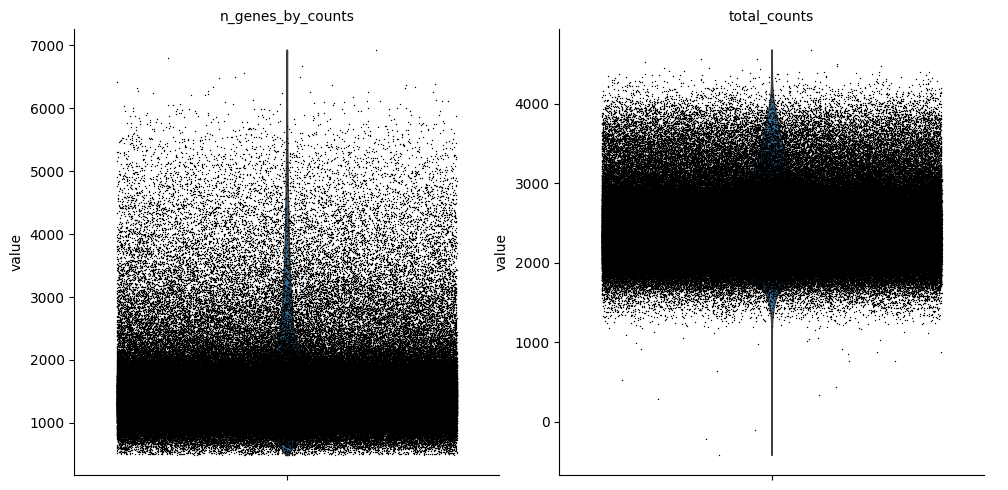

In [13]:
mdata['gex'].var["mt"] = mdata['gex'].var_names.str.startswith("MT-")
# ribosomal genes
mdata['gex'].var["ribo"] = mdata['gex'].var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
mdata['gex'].var["hb"] = mdata['gex'].var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    mdata['gex'], qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

sc.pl.violin(
    mdata['gex'],
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [14]:
# check invalid counts
import numpy as np
from scipy import sparse

X = mdata['gex'].X
if sparse.issparse(X):
    print("NaN:", np.isnan(X.data).sum())
    print("Inf:", np.isinf(X.data).sum())
else:
    print("NaN:", np.isnan(X).sum())
    print("Inf:", np.isinf(X).sum())
    
cell_sums = np.array(mdata['gex'].X.sum(axis=1)).flatten()
print("Zero-count cells:", np.sum(cell_sums == 0))
print("Min counts:", cell_sums.min())
print(X.min(), X.max())

NaN: 0
Inf: 0
Zero-count cells: 0
Min counts: -417.69653
-67.67877 460.98032


In [15]:
X = mdata['gex'].layers['raw']
cell_sums = np.array(X.sum(axis=1)).flatten()
print("Zero-count cells:", np.sum(cell_sums == 0))
print("Min counts:", cell_sums.min())
print(X.min(), X.max())

Zero-count cells: 0
Min counts: 503.0
0.0 162415.0


In [16]:
mdata.mod['gex'] = mdata['gex'].copy()
mdata['gex'].layers['scaled'] = mdata['gex'].X
mdata['gex'].X = mdata['gex'].layers['raw'].copy()

In [17]:
# saved data already filtered and normalized 

# sc.pp.filter_cells(mdata['gex'], min_genes= 100)
# sc.pp.filter_cells(mdata['gex'], max_genes= 6000)

# sc.pp.filter_cells(mdata['gex'], min_counts=1000)
# sc.pp.filter_cells(mdata['gex'], max_counts=5000)

# sc.pp.filter_genes(mdata['gex'], min_cells=20)

sc.pp.normalize_total(mdata['gex'])
sc.pp.log1p(mdata['gex'])

In [18]:
print(mdata['gex'].X.min(), mdata['gex'].X.max())

0.0 8.682486


In [19]:
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
# mdata = mdata_utils.sync_mdata_obs(mdata)

In [20]:
ribo_genes = [g for g in mdata['gex'].var_names if g.startswith(("RPS", "RPL", "MRPS", "MRPL"))]
mito_genes = [g for g in mdata['gex'].var_names if g.startswith("MT-")]
tcr_noise = [g for g in mdata['gex'].var_names if g.startswith(("TRAV", "TRBV", "TRAJ", "TRBJ", "TRAC", "TRBC", "TRDV", "TRGV"))]

# stress_genes = ["HSPA1A", "HSPA1B", "HSPH1", "DNAJB1",
#                 "FOS", "JUN", "JUNB", "EGR1", "DUSP1",
#                 "ZFP36", "ATF3", "NR4A1", "NR4A2"]
# FOS/JUN family especially common artifacts in T cell DEG lists
mt_explicit = [
    "ATP6", "ATP8",      # ATP synthase
    "COX1", "COX2", "COX3",   # cytochrome c oxidase
    "ND1", "ND2", "ND3", "ND4", "ND4L", "ND5", "ND6",  # NADH dehydrogenase
    "CYB",               # cytochrome b
    "RNR1", "RNR2",      # mitochondrial rRNA
]
noise_mt = [g for g in mdata['gex'].var_names if g in mt_explicit]

noise_genes = set(
    ribo_genes +
    mito_genes +
    tcr_noise + noise_mt)

mdata['gex'].var_names_make_unique()
TCR_gene_mask = mdata['gex'].var_names.isin(noise_genes)
mdata = mdata[:, ~TCR_gene_mask]

In [21]:
mdata['gex'].obs['COMBAT_ID'].value_counts()

COMBAT_ID
S00005    12488
S00052     9348
N00023     8270
S00045     8043
H00067     6943
          ...  
U00605      260
U00607      140
U00504       53
G05092        3
S00030        1
Name: count, Length: 124, dtype: int64

In [22]:
trav_rna = mdata['gex'].var_names[mdata['gex'].var_names.str.startswith('TRAJ')]
print(f"TRAV genes in RNA: {len(trav_rna)}")

TRAV genes in RNA: 0


In [23]:
# Compute top-k HVGs per COMBAT_ID on GEX, then replace GEX matrix with HVG-only genes.
import scanpy as sc
import numpy as np

if mdata is None:
    raise RuntimeError("Run the load cell first.")

K_HVG = 200
GROUP_KEY = "COMBAT_ID"
MIN_CELLS_PER_GROUP = 50

gex = mdata.mod["gex"]
if gex.n_vars == 0:
    raise RuntimeError("mdata.mod['gex'] has 0 genes. Reload raw mdata before HVG selection.")
if GROUP_KEY not in gex.obs.columns:
    raise KeyError(f"{GROUP_KEY!r} not found in mdata.mod['gex'].obs")

genes_union: set[str] = set()
skipped: list[tuple[object, str]] = []
counts = gex.obs[GROUP_KEY].value_counts(dropna=True)

for gid, n in counts.items():
    if n < MIN_CELLS_PER_GROUP:
        skipped.append((gid, f"only {n} cells (< {MIN_CELLS_PER_GROUP})"))
        continue

    sub = gex[gex.obs[GROUP_KEY] == gid].copy()
    sub = sub[:, sub.var_names.notna()].copy()
    # try:
    
    sc.pp.highly_variable_genes(
        sub,
        n_top_genes=min(K_HVG, sub.n_vars),
        inplace=True,
        # flavor='seurat_v3',   # use raw count
    )
    # except Exception as exc:  # noqa: BLE001
    #     skipped.append((gid, repr(exc)))
    #     continue

    hv = sub.var["highly_variable"].fillna(False).to_numpy(dtype=bool)
    genes_union.update(sub.var_names[hv].astype(str))

hvg_union = sorted(genes_union)
if len(hvg_union) == 0:
    raise RuntimeError("HVG union is empty. Check skipped errors above.")

mask = np.isin(gex.var_names.astype(str), hvg_union)
selected = gex.var_names[mask]

gex.var["hvg_union_COMBAT_ID"] = mask
gex.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
gex.uns["hvg_union_COMBAT_ID_meta"] = {
    "group_key": GROUP_KEY,
    "k_per_group": K_HVG,
    "min_cells_per_group": MIN_CELLS_PER_GROUP,
    "flavor": "scanpy_default",
    "layer": "scanpy_default",
    "n_groups": int(len(counts)),
    "n_union_genes": int(len(hvg_union)),
}

gex_hvg = gex[:, selected].copy()
gex_hvg.var["hvg_union_COMBAT_ID"] = True
gex_hvg.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
gex_hvg.uns["hvg_union_COMBAT_ID_meta"] = dict(gex.uns["hvg_union_COMBAT_ID_meta"])

mdata.mod["gex"] = gex_hvg
mdata.uns["hvg_union_COMBAT_ID_meta"] = dict(gex_hvg.uns["hvg_union_COMBAT_ID_meta"])

print(f"Selected HVG union genes: {len(hvg_union):,}")
print(f"New GEX shape: {mdata.mod['gex'].n_obs:,} cells x {mdata.mod['gex'].n_vars:,} genes")
print("GEX n_vars equals union size:", mdata.mod["gex"].n_vars == len(hvg_union))
if skipped:
    print(f"Skipped {len(skipped)} groups (showing up to 8):", skipped[:8])

/scratch/slurm-9266176/ipykernel_2015799/1047934953.py:51: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  gex.var["hvg_union_COMBAT_ID"] = mask
/scratch/slurm-9266176/ipykernel_2015799/1047934953.py:69: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  mdata.uns["hvg_union_COMBAT_ID_meta"] = dict(gex_hvg.uns["hvg_union_COMBAT_ID_meta"])
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1461

Selected HVG union genes: 4,646
New GEX shape: 401,488 cells x 4,646 genes
GEX n_vars equals union size: True
Skipped 2 groups (showing up to 8): [('G05092', 'only 3 cells (< 50)'), ('S00030', 'only 1 cells (< 50)')]


In [24]:
sc.pp.scale(mdata['gex'], max_value=10)

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [25]:
mdata['gex'].obs['Annotation_cell_type']

AAACCTGAGCGGATCA-1-gPlexA1      T
AAACCTGAGTTAACGA-1-gPlexA1    nan
AAACCTGCAGCTCGAC-1-gPlexA1      T
AAACCTGCATCTATGG-1-gPlexA1      T
AAACCTGGTCTCTCTG-1-gPlexA1      T
                             ... 
TTTGGTTTCCCTTGCA-1-gPlexK7    nan
TTTGGTTTCCTCAACC-1-gPlexK7      T
TTTGGTTTCTCGATGA-1-gPlexK7      T
TTTGTCACACCACGTG-1-gPlexK7      T
TTTGTCAGTTACCGAT-1-gPlexK7      T
Name: Annotation_cell_type, Length: 401488, dtype: category
Categories (9, object): ['B', 'ERYTH', 'HSC', 'MNP', ..., 'PB', 'PLT', 'T', 'nan']

In [26]:
# mdata = mdata_utils.sync_mdata_obs(mdata)
# mdata

In [27]:
# Safe way — filter on mdata.obs, then subset by integer index
# obs_keep = mdata.obs_names[mdata.obs['gex:Annotation_cell_type'].isin(['T', 'NK'])]
# idx = mdata.obs_names.get_indexer(obs_keep)
# idx = idx[idx >= 0]
# mdata_sub = mdata[idx, :].copy()

## Barch correction

In [29]:
sc.pp.pca(mdata["gex"], n_comps = 50)

In [30]:
X = np.asarray(mdata["gex"].obsm['X_pca'], dtype=np.float64)
bad = ~np.isfinite(X).all(axis=1)
if bad.any():
    mdata["gex"] = mdata["gex"][~bad].copy()
    X = np.asarray(mdata["gex"].obsm['X_pca'], dtype=np.float64)
mdata["gex"].obsm['X_pca'] = np.ascontiguousarray(X)

# mdata["gex"].obsm['X_pca'] = np.asarray(mdata["gex"].obsm['X_pca'], dtype=np.float64)
# mdata["gex"].obs['GSE'] = mdata["gex"].obs['GSE'].astype("string").fillna("unknown").astype("category")
# mdata["gex"].obs['GSE'] = mdata["gex"].obs['GSE'].astype("object").astype("category")

KeyError: 'GSE'

In [31]:
import scanpy.external as sce
sce.pp.harmony_integrate(mdata["gex"], key=['scRNASeq_sample_ID', 'Institute', 'Pool_ID'],  basis='X_pca', max_iter_harmony=10, 
                          theta = 4, lamb = 1.5, sigma=0.1, tau=1)

2026-05-14 14:21:46,475 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-14 14:21:57,703 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-14 14:21:58,280 - harmonypy - INFO - Iteration 1 of 30
2026-05-14 14:23:12,509 - harmonypy - INFO - Iteration 2 of 30
2026-05-14 14:24:29,414 - harmonypy - INFO - Iteration 3 of 30
2026-05-14 14:25:36,469 - harmonypy - INFO - Iteration 4 of 30
2026-05-14 14:26:45,880 - harmonypy - INFO - Iteration 5 of 30
2026-05-14 14:28:00,347 - harmonypy - INFO - Iteration 6 of 30
2026-05-14 14:29:04,815 - harmonypy - INFO - Iteration 7 of 30
2026-05-14 14:29:49,372 - harmonypy - INFO - Iteration 8 of 30
2026-05-14 14:30:26,332 - harmonypy - INFO - Iteration 9 of 30
2026-05-14 14:31:03,896 - harmonypy - INFO - Iteration 10 of 30
2026-05-14 14:31:41,328 - harmonypy - INFO - Iteration 11 of 30
2026-05-14 14:32:18,978 - harmonypy - INFO - Iteration 12 of 30
2026-05-14 14:32:57,619 - harmonypy - INFO - Iteration 13 of

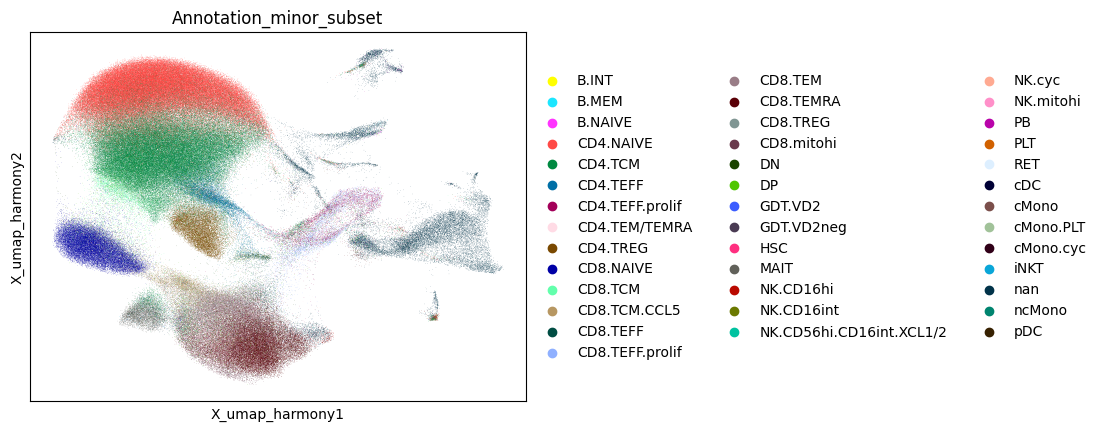

In [32]:
sc.pp.neighbors(mdata["gex"], n_neighbors = 30, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['Annotation_minor_subset'], ncols=2,)

In [34]:
# Plot precomputed UMAP (subsample for speed if the object is very large)
# adata = mdata_sub.mod["gex"]
# sc.pp.pca(adata, n_comps=50)
# sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')
# sc.tl.umap(adata)

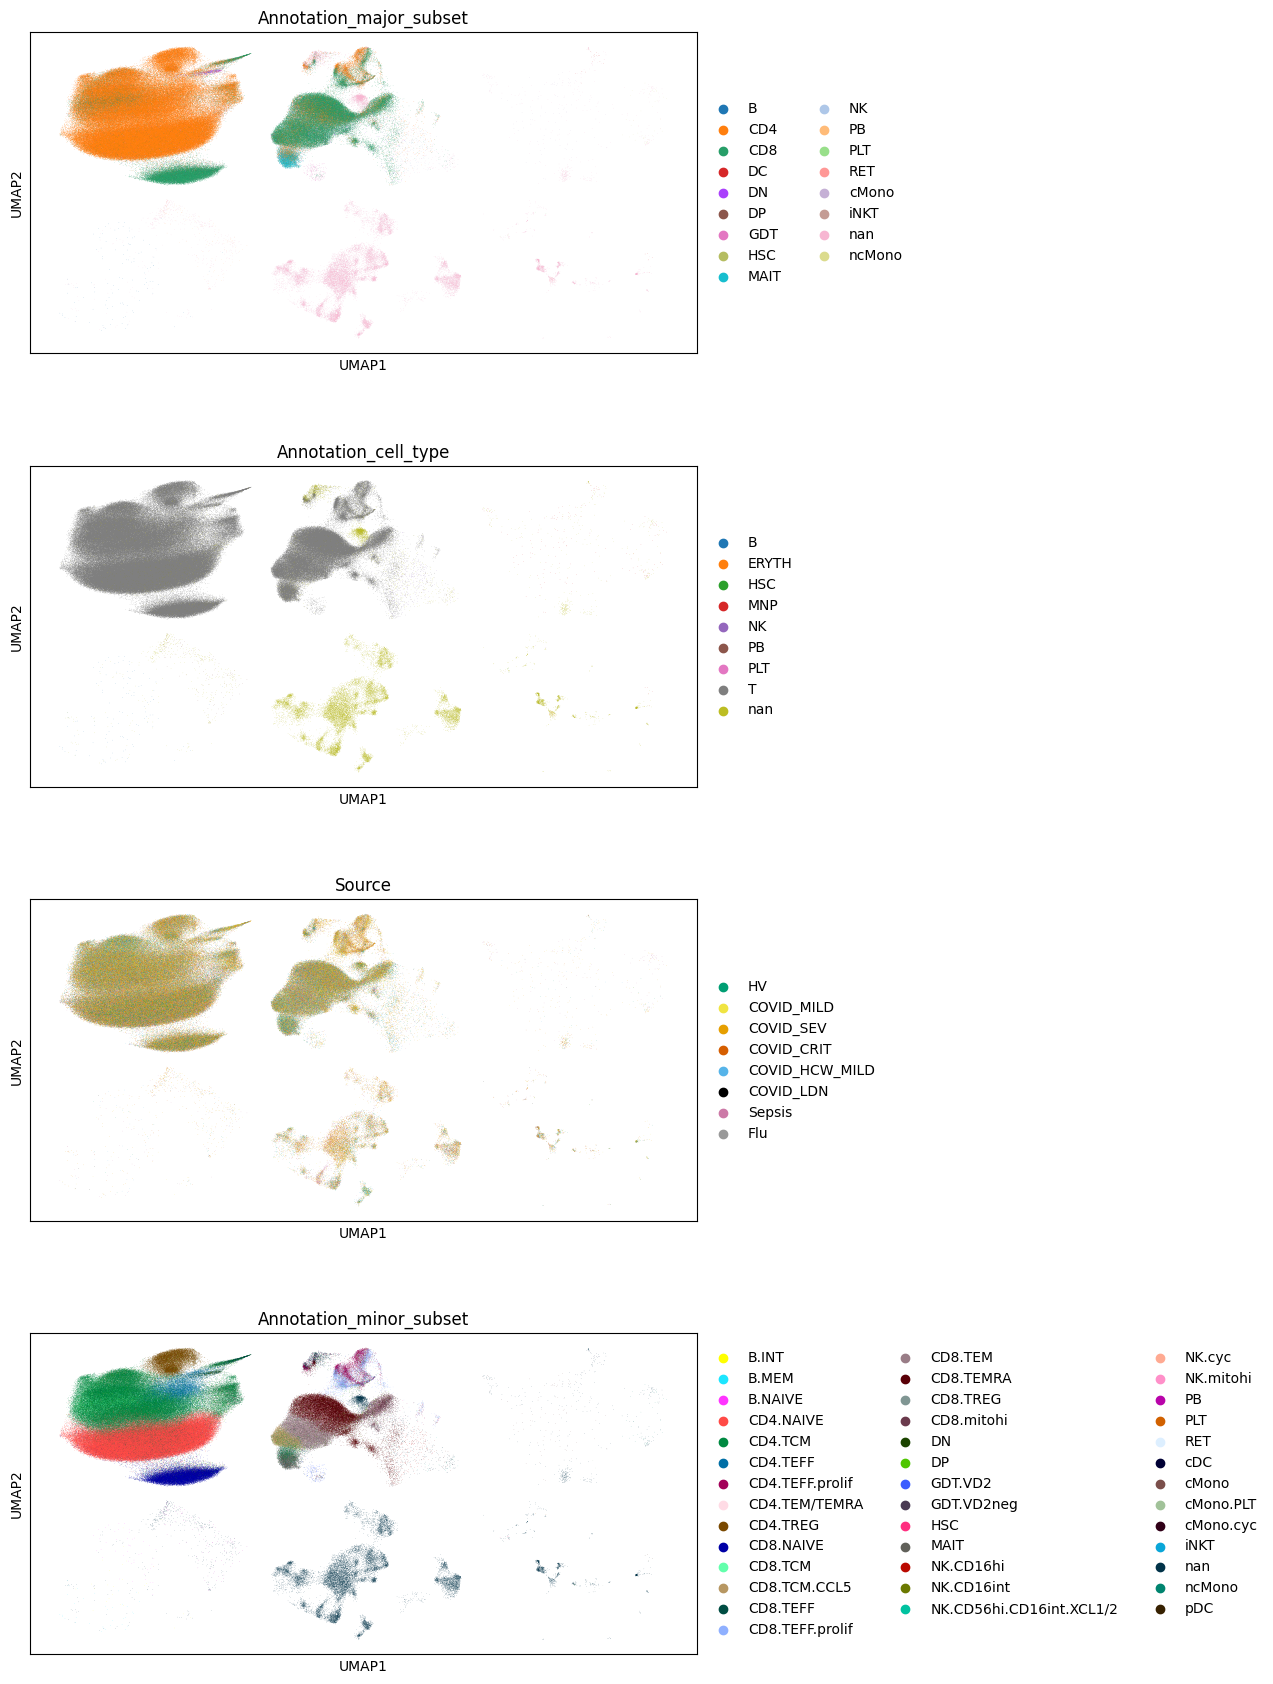

In [36]:
cols = [c for c in (
    "Annotation_major_subset",
    "Annotation_cell_type",
    "Source",
    'Annotation_minor_subset',
) if c in mdata['gex'].obs]

sc.pl.umap(mdata['gex'], color=cols, ncols=1, wspace=0.45, hspace=0.35)

In [ ]:
# 'Annotation_minor_subset'

In [37]:
mdata.write(BASE / "common_HV200.h5mu")

/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
